<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/Camino_Gibbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2171/3763069818.py:62: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Coste $C(\mathbf{X})$')


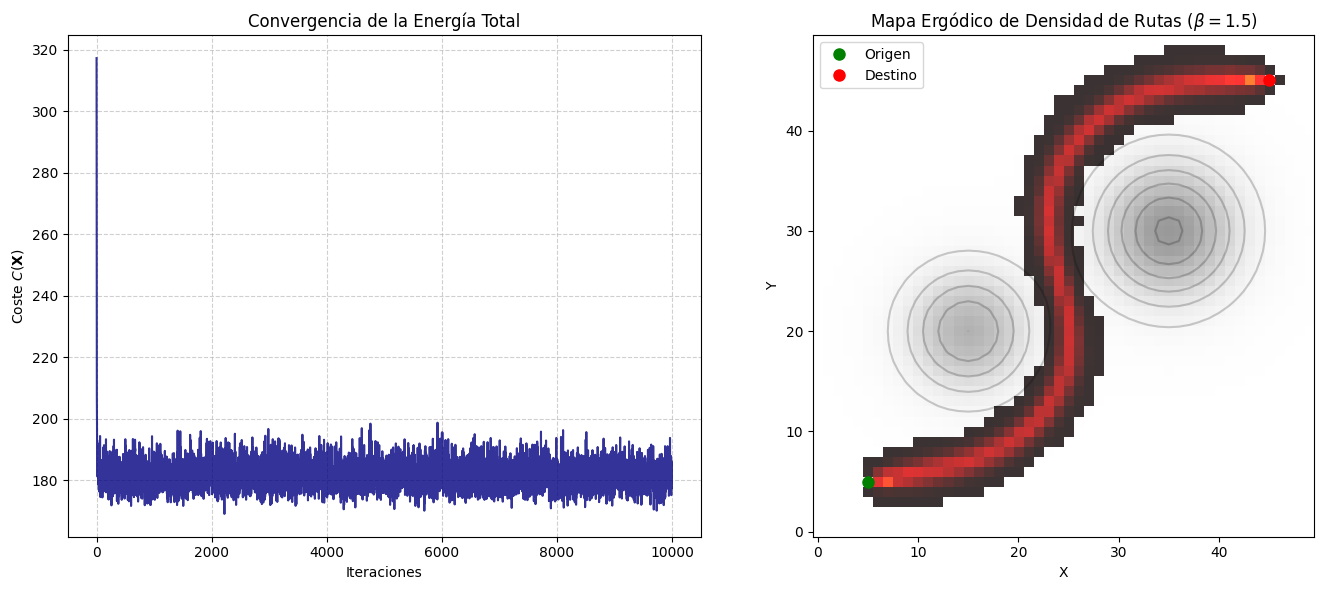

In [1]:
import numpy as np
import matplotlib.pyplot as plt

grid_size = 50
cost_map = np.zeros((grid_size, grid_size))
X_grid, Y_grid = np.meshgrid(np.arange(grid_size), np.arange(grid_size), indexing='ij')

cost_map += 20 * np.exp(-((X_grid - 15)**2 + (Y_grid - 20)**2) / 40)
cost_map += 25 * np.exp(-((X_grid - 35)**2 + (Y_grid - 30)**2) / 50)

T = 40
path = np.zeros((T, 2), dtype=int)
path[:, 0] = np.linspace(5, 45, T).astype(int)
path[:, 1] = np.linspace(5, 45, T).astype(int)

beta = 1.5
lam = 1.0
iterations = 10000
burn_in = 2000

energy_hist = np.zeros(iterations)
density_map = np.zeros((grid_size, grid_size))
rng = np.random.default_rng(seed=123)

def compute_total_energy(p):
    e_obs = np.sum(cost_map[p[:, 0], p[:, 1]])
    e_elast = lam * np.sum(np.sum((p[1:] - p[:-1])**2, axis=1))
    return e_obs + e_elast

for i in range(iterations):
    for t in range(1, T - 1):
        cx, cy = path[t]

        x_min, x_max = max(0, cx - 2), min(grid_size, cx + 3)
        y_min, y_max = max(0, cy - 2), min(grid_size, cy + 3)

        x_vals = np.arange(x_min, x_max)
        y_vals = np.arange(y_min, y_max)
        candidates = np.transpose([np.tile(x_vals, len(y_vals)), np.repeat(y_vals, len(x_vals))])

        e_local = cost_map[candidates[:, 0], candidates[:, 1]]
        e_local = e_local + lam * np.sum((candidates - path[t-1])**2, axis=1)
        e_local = e_local + lam * np.sum((candidates - path[t+1])**2, axis=1)

        log_probs = -beta * e_local
        log_probs = log_probs - np.max(log_probs)
        probs = np.exp(log_probs)
        probs = probs / np.sum(probs)

        chosen_idx = rng.choice(len(candidates), p=probs)
        path[t] = candidates[chosen_idx]

    energy_hist[i] = compute_total_energy(path)
    if i > burn_in:
        density_map[path[:, 0], path[:, 1]] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(energy_hist, color='navy', alpha=0.8)
ax1.set_title('Convergencia de la Energía Total')
ax1.set_xlabel('Iteraciones')
ax1.set_ylabel('Coste $C(\mathbf{X})$')
ax1.grid(True, linestyle='--', alpha=0.6)

im = ax2.imshow(cost_map.T, origin='lower', cmap='Greys', alpha=0.4)
ax2.contour(X_grid, Y_grid, cost_map, levels=6, colors='black', alpha=0.2)
density_masked = np.ma.masked_where(density_map == 0, density_map)
im2 = ax2.imshow(density_masked.T, origin='lower', cmap='hot', alpha=0.8)

ax2.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='Origen')
ax2.plot(path[-1, 0], path[-1, 1], 'ro', markersize=8, label='Destino')
ax2.set_title(f'Mapa Ergódico de Densidad de Rutas ($\\beta={beta}$)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()

plt.tight_layout()
plt.savefig('GIBBS_TRAYECTORIA.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [2]:
from google.colab import files
files.download("GIBBS_TRAYECTORIA.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>